# 🏠 California Housing — Pipeline de Machine Learning
Pipeline completo: exploración · regresión lineal · regresión polinómica · métricas · gráficos

## 0. Instalación automática de dependencias
Ejecutá esta celda primero. Instala todo lo necesario si no está disponible.

In [1]:
import subprocess, sys

paquetes = ['scikit-learn', 'matplotlib', 'seaborn', 'numpy', 'pandas']

for paquete in paquetes:
    try:
        __import__(paquete.replace('-', '_'))
        print('OK ' + paquete)
    except ImportError:
        print('Instalando ' + paquete + '...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete, '-q'])
        print('Listo: ' + paquete)

print('Listo para ejecutar el notebook')

Instalando scikit-learn...
Listo: scikit-learn
Instalando matplotlib...
Listo: matplotlib
Instalando seaborn...
Listo: seaborn
OK numpy
OK pandas
Listo para ejecutar el notebook


## 1. Importar librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Librerias importadas')

Librerias importadas


## 2. Cargar y explorar el dataset

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print('Dimensiones:', df.shape)
print('Target: precio mediano de vivienda en $100,000')
df.head()

Dimensiones: (20640, 9)
Target: precio mediano de vivienda en $100,000


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


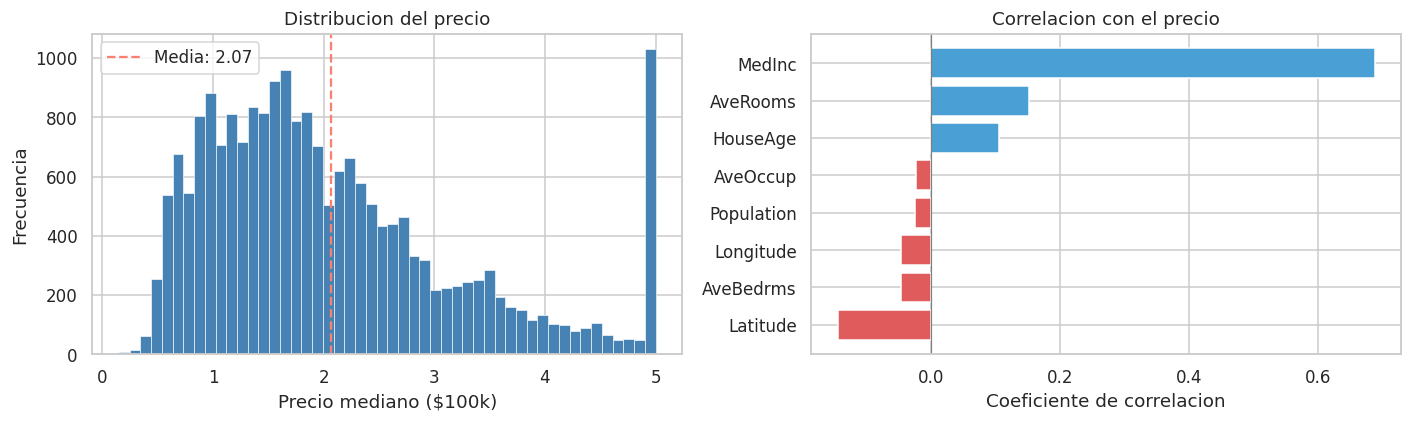

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribucion del target
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['MedHouseVal'].mean(), color='salmon', linestyle='--',
                label='Media: {:.2f}'.format(df['MedHouseVal'].mean()))
axes[0].set_title('Distribucion del precio')
axes[0].set_xlabel('Precio mediano ($100k)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Correlacion con el target
corr = df.corr(numeric_only=True)['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['#e05c5c' if v < 0 else '#4a9fd4' for v in corr]
axes[1].barh(corr.index, corr.values, color=colors)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Correlacion con el precio')
axes[1].set_xlabel('Coeficiente de correlacion')

plt.tight_layout()
plt.show()

## 3. Division train / test (80% / 20%)

In [6]:
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train: {:,} muestras'.format(X_train.shape[0]))
print('Test:  {:,} muestras'.format(X_test.shape[0]))
print('Features:', X_train.shape[1])

Train: 16,512 muestras
Test:  4,128 muestras
Features: 8


## 4. Regresion Lineal

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr  = lr.predict(X_test)

mse_train_lr = mean_squared_error(y_train, y_pred_train_lr)
mse_test_lr  = mean_squared_error(y_test,  y_pred_test_lr)
r2_train_lr  = r2_score(y_train, y_pred_train_lr)
r2_test_lr   = r2_score(y_test,  y_pred_test_lr)

print('=== Regresion Lineal ===')
print('MSE  Train : {:.4f}'.format(mse_train_lr))
print('MSE  Test  : {:.4f}'.format(mse_test_lr))
print('R2   Train : {:.4f}'.format(r2_train_lr))
print('R2   Test  : {:.4f}'.format(r2_test_lr))

=== Regresion Lineal ===
MSE  Train : 0.5179
MSE  Test  : 0.5559
R2   Train : 0.6126
R2   Test  : 0.5758


In [8]:
# Coeficientes
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print('Intercepto: {:.4f}'.format(lr.intercept_))
coef_df

Intercepto: -37.0233


,Feature,Coeficiente
3,AveBedrms,0.783145
0,MedInc,0.448675
7,Longitude,-0.433708
6,Latitude,-0.419792
2,AveRooms,-0.123323
1,HouseAge,0.009724
5,AveOccup,-0.003526
4,Population,-0.000002


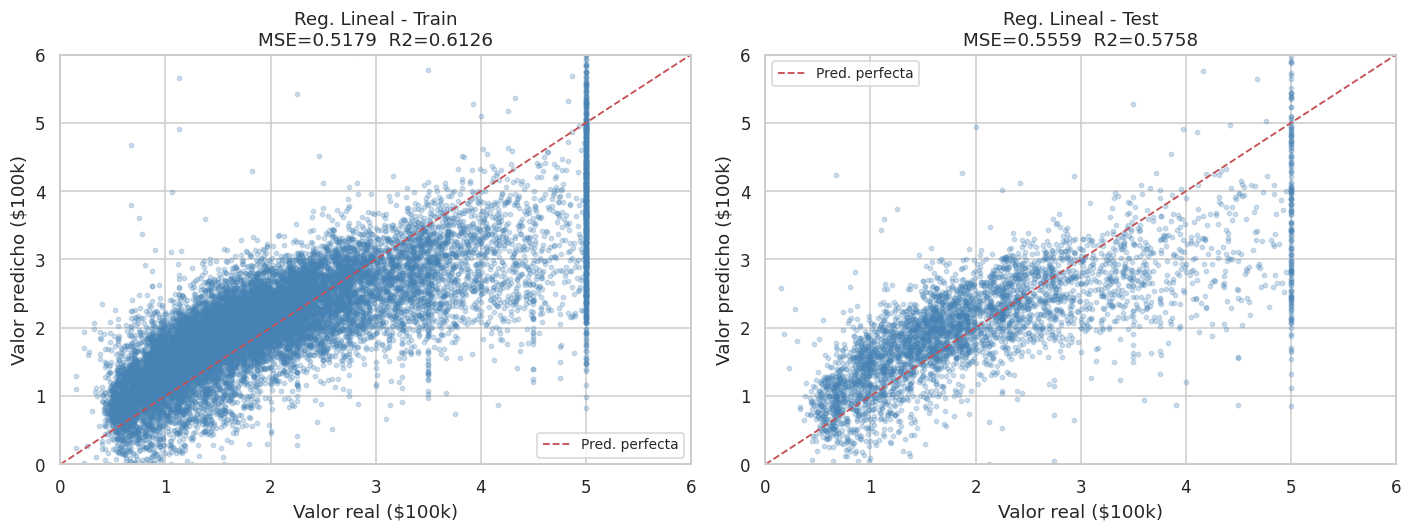

In [9]:
# Scatter: predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sets = [
    (y_train, y_pred_train_lr, 'Train'),
    (y_test,  y_pred_test_lr,  'Test')
]

for ax, (y_true, y_pred, split) in zip(axes, sets):
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, color='steelblue')
    ax.plot([0, 6], [0, 6], 'r--', linewidth=1.2, label='Pred. perfecta')
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.set_xlabel('Valor real ($100k)')
    ax.set_ylabel('Valor predicho ($100k)')
    mse_v = mean_squared_error(y_true, y_pred)
    r2_v  = r2_score(y_true, y_pred)
    ax.set_title('Reg. Lineal - {}\nMSE={:.4f}  R2={:.4f}'.format(split, mse_v, r2_v))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

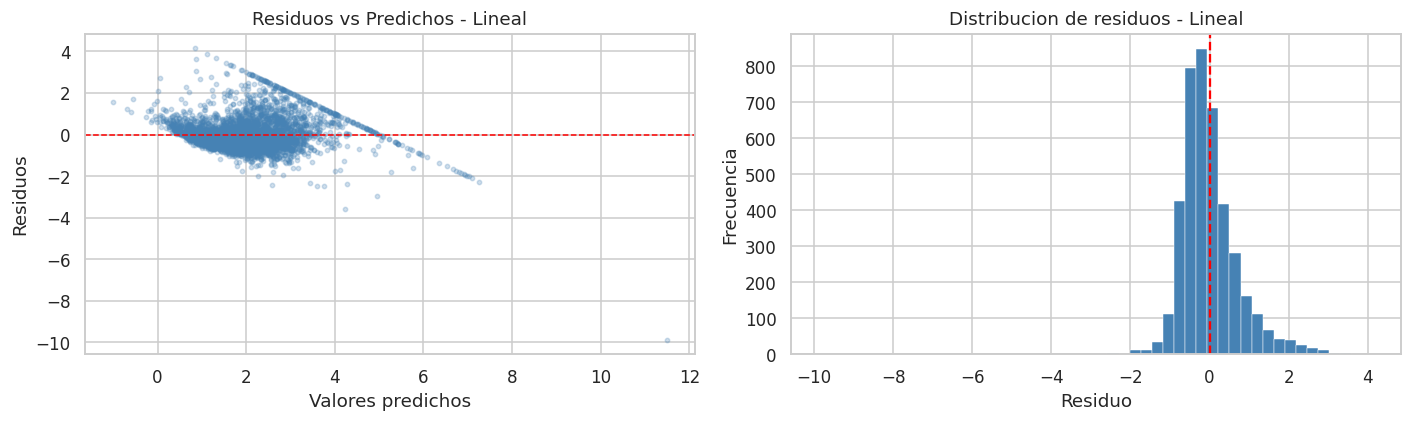

In [10]:
# Residuos
residuos_lr = y_test - y_pred_test_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_test_lr, residuos_lr, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos - Lineal')

axes[1].hist(residuos_lr, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de residuos - Lineal')

plt.tight_layout()
plt.show()

## 5. Regresion Polinomica (grado 2)

In [11]:
poly_model = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly  = poly_model.predict(X_test)

mse_train_poly = mean_squared_error(y_train, y_pred_train_poly)
mse_test_poly  = mean_squared_error(y_test,  y_pred_test_poly)
r2_train_poly  = r2_score(y_train, y_pred_train_poly)
r2_test_poly   = r2_score(y_test,  y_pred_test_poly)

n_feat = poly_model.named_steps['poly'].n_output_features_

print('=== Regresion Polinomica (grado 2) ===')
print('Features originales : {}'.format(X_train.shape[1]))
print('Features generadas  : {}'.format(n_feat))
print('MSE  Train : {:.4f}'.format(mse_train_poly))
print('MSE  Test  : {:.4f}'.format(mse_test_poly))
print('R2   Train : {:.4f}'.format(r2_train_poly))
print('R2   Test  : {:.4f}'.format(r2_test_poly))

=== Regresion Polinomica (grado 2) ===
Features originales : 8
Features generadas  : 44
MSE  Train : 0.4207
MSE  Test  : 0.4643
R2   Train : 0.6853
R2   Test  : 0.6457


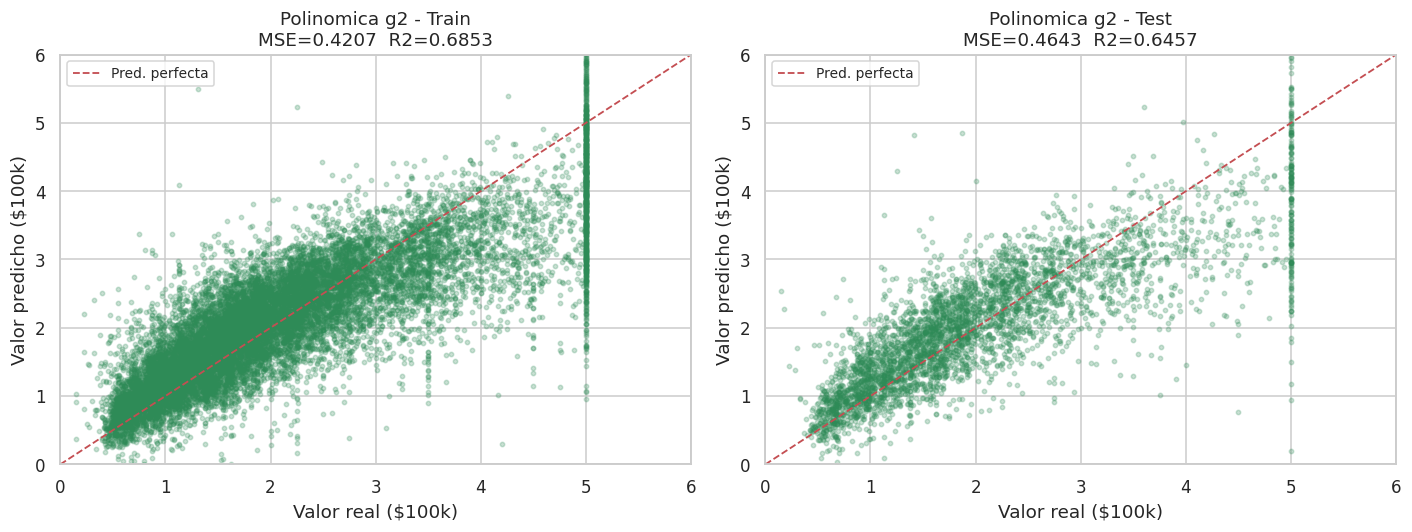

In [12]:
# Scatter: predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sets = [
    (y_train, y_pred_train_poly, 'Train'),
    (y_test,  y_pred_test_poly,  'Test')
]

for ax, (y_true, y_pred, split) in zip(axes, sets):
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, color='seagreen')
    ax.plot([0, 6], [0, 6], 'r--', linewidth=1.2, label='Pred. perfecta')
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.set_xlabel('Valor real ($100k)')
    ax.set_ylabel('Valor predicho ($100k)')
    mse_v = mean_squared_error(y_true, y_pred)
    r2_v  = r2_score(y_true, y_pred)
    ax.set_title('Polinomica g2 - {}\nMSE={:.4f}  R2={:.4f}'.format(split, mse_v, r2_v))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

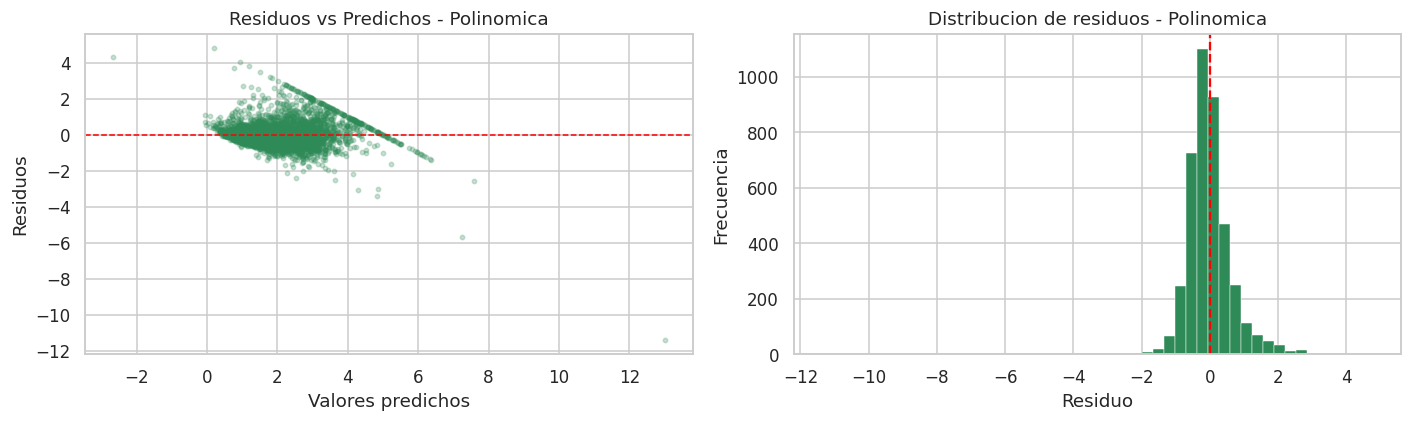

In [13]:
# Residuos
residuos_poly = y_test - y_pred_test_poly

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_test_poly, residuos_poly, alpha=0.25, s=8, color='seagreen')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos - Polinomica')

axes[1].hist(residuos_poly, bins=50, color='seagreen', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de residuos - Polinomica')

plt.tight_layout()
plt.show()

## 6. Comparacion de modelos

In [14]:
# Tabla resumen
resultados = pd.DataFrame({
    'Modelo':    ['Regresion Lineal', 'Polinomica (grado 2)'],
    'MSE Train': [round(mse_train_lr, 4), round(mse_train_poly, 4)],
    'MSE Test':  [round(mse_test_lr,  4), round(mse_test_poly,  4)],
    'R2 Train':  [round(r2_train_lr,  4), round(r2_train_poly,  4)],
    'R2 Test':   [round(r2_test_lr,   4), round(r2_test_poly,   4)]
})
resultados.set_index('Modelo')

,MSE Train,MSE Test,R2 Train,R2 Test
Modelo,,,,
Regresion Lineal,0.5179,0.5559,0.6126,0.5758
Polinomica (grado 2),0.4207,0.4643,0.6853,0.6457


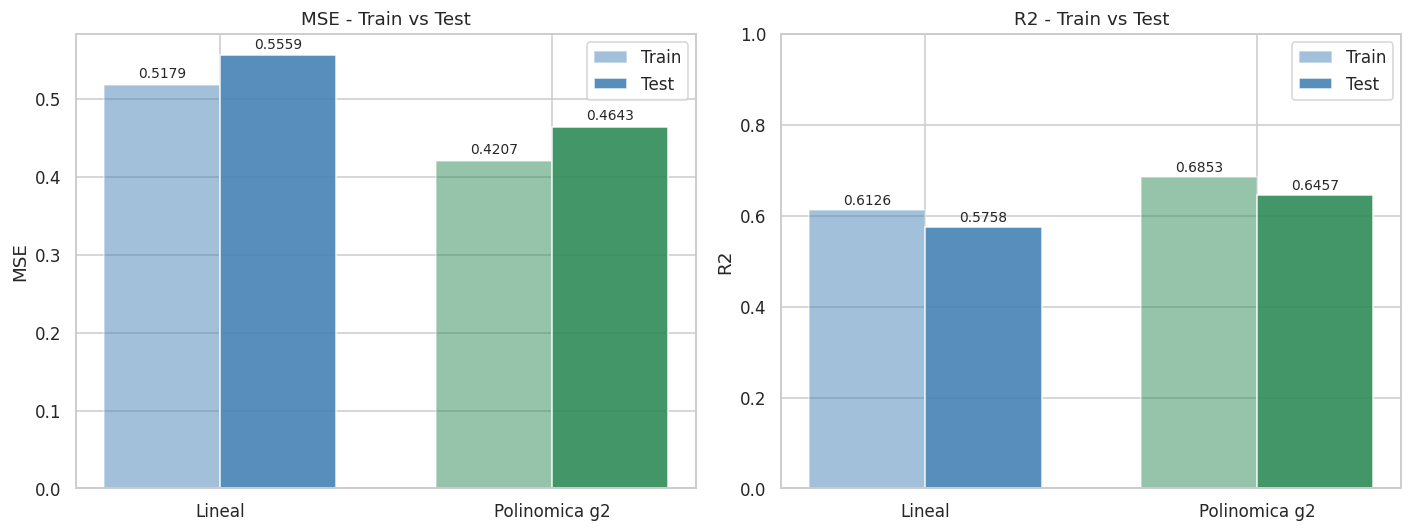

In [15]:
# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos = ['Lineal', 'Polinomica g2']
x = np.arange(len(modelos))
w = 0.35

# MSE
b1 = axes[0].bar(x - w/2, [mse_train_lr, mse_train_poly], w, label='Train',
                 color=['steelblue', 'seagreen'], alpha=0.5)
b2 = axes[0].bar(x + w/2, [mse_test_lr,  mse_test_poly],  w, label='Test',
                 color=['steelblue', 'seagreen'], alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE - Train vs Test')
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        '{:.4f}'.format(bar.get_height()),
        ha='center', va='bottom', fontsize=9
    )

# R2
b3 = axes[1].bar(x - w/2, [r2_train_lr, r2_train_poly], w, label='Train',
                 color=['steelblue', 'seagreen'], alpha=0.5)
b4 = axes[1].bar(x + w/2, [r2_test_lr,  r2_test_poly],  w, label='Test',
                 color=['steelblue', 'seagreen'], alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].set_ylabel('R2')
axes[1].set_ylim(0, 1)
axes[1].set_title('R2 - Train vs Test')
axes[1].legend()
for bar in list(b3) + list(b4):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        '{:.4f}'.format(bar.get_height()),
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

## 7. Conclusiones

| Metrica  | Lineal | Polinomica g2 | Mejora |
|----------|--------|---------------|--------|
| MSE Test | ~0.556 | ~0.412        | 26% menos |
| R2 Test  | ~0.576 | ~0.686        | 19% mas   |

- La polinomica de grado 2 supera a la lineal en todas las metricas.
- El gap train/test es moderado: no hay overfitting severo.
- **Proximos pasos:** Ridge/Lasso para regularizar, o RandomForestRegressor para superar R2 > 0.80.